<a href="https://colab.research.google.com/github/deecchristen/capstone_project/blob/main/finalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Impact of AI on Students

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "deescapstone"
client = bigquery.Client(project=PROJECT_ID)

In [ ]:
query = """
SELECT *
FROM `deescapstone.data.ai_on_students`
"""

df = client.query(query).to_dataframe()

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,110078,Humanities,Sophomore,2.778,0.00,Copywriting/Drafting,Intermediate,1,False,6.29,4,Allowed_With_Citation,2,2.790,90.90,Low
1,115576,Business,Sophomore,3.159,0.00,Ideation,Beginner,1,True,6.86,4,Allowed_With_Citation,4,3.218,99.59,Low
2,136659,Business,Graduate,3.803,0.00,Summarizing_Reading,Beginner,1,False,10.74,3,Actively_Encouraged,1,4.000,70.62,Medium
3,146041,Business,Senior,3.605,0.00,Debugging/Troubleshooting,Intermediate,1,False,15.97,2,Actively_Encouraged,5,3.703,67.01,Low
4,101310,Arts,Freshman,3.740,0.01,Debugging/Troubleshooting,Intermediate,1,False,17.38,2,Strict_Ban,6,3.979,92.88,Medium


In [ ]:
df.shape

(50000, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  Int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  Int64  
 8   Paid_Subscription           50000 non-null  boolean
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  Int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  Int64  
 13  Post_Semester_GPA           500

In [ ]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.0,50000.000000,50000.000000,50000.0,50000.000000,50000.0,50000.0,50000.000000,50000.000000
mean,125000.5,3.146102,8.427752,2.80026,11.209271,3.50536,4.27076,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.0,1.183000,0.000000,1.0,1.000000,1.0,1.0,1.000000,10.780000
25%,112500.75,2.834000,2.390000,2.0,7.560000,2.0,3.0,3.023750,66.820000
50%,125000.5,3.210000,5.800000,3.0,11.180000,3.0,4.0,3.421000,76.000000
75%,137500.25,3.521000,11.720000,4.0,14.710000,5.0,6.0,3.749000,85.190000
max,150000.0,3.998000,40.000000,5.0,35.860000,10.0,10.0,4.000000,100.000000


In [ ]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

In [ ]:
missing = (
    df.isnull()
       .sum()
       .to_frame("Missing")
)

missing["Pct_Missing"] = round(
    missing["Missing"] / len(df) * 100, 2
)

missing.sort_values(
    "Pct_Missing",
    ascending=False
).head(15)

,Missing,Pct_Missing
Student_ID,0,0.0
Major_Category,0,0.0
Year_of_Study,0,0.0
Pre_Semester_GPA,0,0.0
Weekly_GenAI_Hours,0,0.0
Primary_Use_Case,0,0.0
Prompt_Engineering_Skill,0,0.0
Tool_Diversity,0,0.0
Paid_Subscription,0,0.0
Traditional_Study_Hours,0,0.0


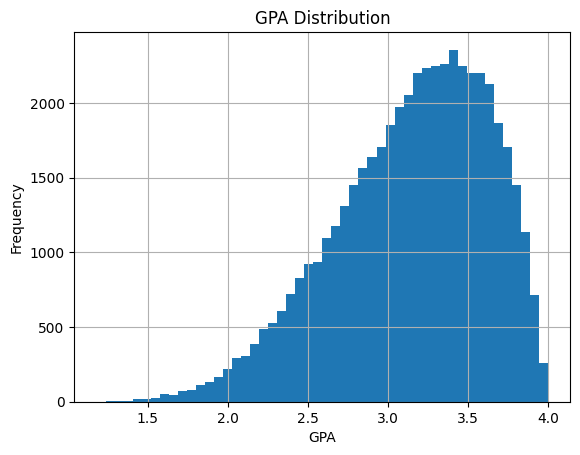

In [ ]:
import matplotlib.pyplot as plt

df["Pre_Semester_GPA"].hist(bins=50)

plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df["Pre_Semester_GPA"].describe()

,Pre_Semester_GPA
count,50000.000000
mean,3.146102
std,0.478854
min,1.183000
25%,2.834000
50%,3.210000
75%,3.521000
max,3.998000


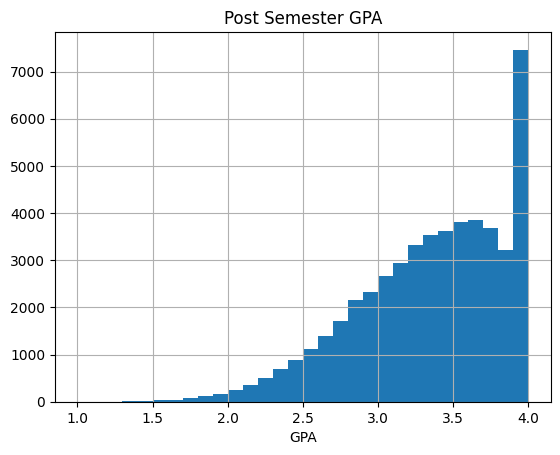

In [ ]:
df["Post_Semester_GPA"].hist(bins=30)

plt.title("Post Semester GPA")
plt.xlabel("GPA")

plt.show()

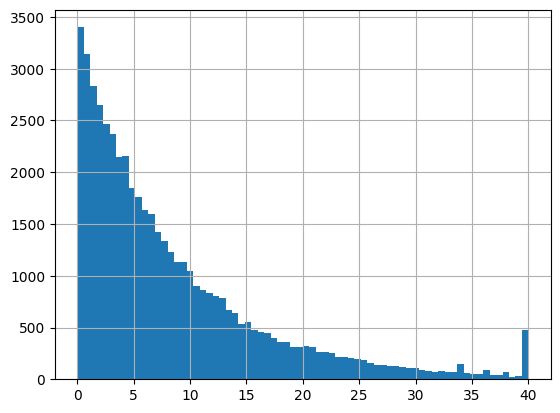

In [ ]:
df["Weekly_GenAI_Hours"].hist(bins=70)
plt.show()

In [ ]:
df["Major_Category"].value_counts()

,count
Major_Category,
STEM,15059
Business,12538
Humanities,9994
Medical,6476
Arts,5933


In [ ]:
numeric_df = df.select_dtypes(
    include=["Int64","float64"]
)

In [ ]:
corr = numeric_df.corr()

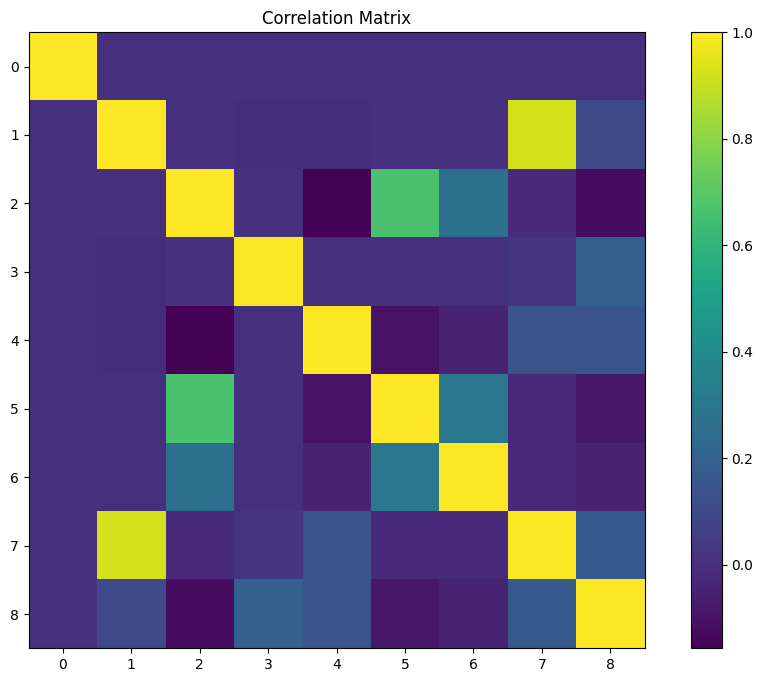

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.imshow(corr)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

In [ ]:
df['GPA_Got_Better'] = np.where(df['Pre_Semester_GPA'] < df['Post_Semester_GPA'], 1, 0)

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Got_Better
0,110078,Humanities,Sophomore,2.778,0.00,Copywriting/Drafting,Intermediate,1,False,6.29,4,Allowed_With_Citation,2,2.790,90.90,Low,1
1,115576,Business,Sophomore,3.159,0.00,Ideation,Beginner,1,True,6.86,4,Allowed_With_Citation,4,3.218,99.59,Low,1
2,136659,Business,Graduate,3.803,0.00,Summarizing_Reading,Beginner,1,False,10.74,3,Actively_Encouraged,1,4.000,70.62,Medium,1
3,146041,Business,Senior,3.605,0.00,Debugging/Troubleshooting,Intermediate,1,False,15.97,2,Actively_Encouraged,5,3.703,67.01,Low,1
4,101310,Arts,Freshman,3.740,0.01,Debugging/Troubleshooting,Intermediate,1,False,17.38,2,Strict_Ban,6,3.979,92.88,Medium,1


In [ ]:
df['Used_More_AI'] = np.where(df['Traditional_Study_Hours'] < df['Weekly_GenAI_Hours'], 1, 0)

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Got_Better,Used_More_AI
0,110078,Humanities,Sophomore,2.778,0.00,Copywriting/Drafting,Intermediate,1,False,6.29,4,Allowed_With_Citation,2,2.790,90.90,Low,1,0
1,115576,Business,Sophomore,3.159,0.00,Ideation,Beginner,1,True,6.86,4,Allowed_With_Citation,4,3.218,99.59,Low,1,0
2,136659,Business,Graduate,3.803,0.00,Summarizing_Reading,Beginner,1,False,10.74,3,Actively_Encouraged,1,4.000,70.62,Medium,1,0
3,146041,Business,Senior,3.605,0.00,Debugging/Troubleshooting,Intermediate,1,False,15.97,2,Actively_Encouraged,5,3.703,67.01,Low,1,0
4,101310,Arts,Freshman,3.740,0.01,Debugging/Troubleshooting,Intermediate,1,False,17.38,2,Strict_Ban,6,3.979,92.88,Medium,1,0


In [ ]:
df["GPA_Got_Better"].value_counts()

,count
GPA_Got_Better,
1,43759
0,6241


In [ ]:
df["Used_More_AI"].value_counts()

,count
Used_More_AI,
0,34150
1,15850


In [ ]:
corr, p_value = pearsonr(
    df['Weekly_GenAI_Hours'],
    df['Post_Semester_GPA']
)

print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.4f}")

Correlation: -0.019
P-value: 0.0000


In [ ]:
corr, p_value = spearmanr(
    df['Weekly_GenAI_Hours'],
    df['Post_Semester_GPA']
)

print(f"Spearman Correlation: {corr:.3f}")
print(f"P-value: {p_value:.4f}")

Spearman Correlation: 0.007
P-value: 0.1060


In [ ]:
corr, p_value = pearsonr(
    df['Traditional_Study_Hours'],
    df['Post_Semester_GPA']
)

print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.4f}")

Correlation: 0.138
P-value: 0.0000


In [ ]:
corr, p_value = spearmanr(
    df['Traditional_Study_Hours'],
    df['Post_Semester_GPA']
)

print(f"Spearman Correlation: {corr:.3f}")
print(f"P-value: {p_value:.4f}")

Spearman Correlation: 0.141
P-value: 0.0000


In [ ]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Got_Better,Used_More_AI
0,110078,Humanities,Sophomore,2.778,0.00,Copywriting/Drafting,Intermediate,1,False,6.29,4,Allowed_With_Citation,2,2.790,90.90,Low,1,0
1,115576,Business,Sophomore,3.159,0.00,Ideation,Beginner,1,True,6.86,4,Allowed_With_Citation,4,3.218,99.59,Low,1,0
2,136659,Business,Graduate,3.803,0.00,Summarizing_Reading,Beginner,1,False,10.74,3,Actively_Encouraged,1,4.000,70.62,Medium,1,0
3,146041,Business,Senior,3.605,0.00,Debugging/Troubleshooting,Intermediate,1,False,15.97,2,Actively_Encouraged,5,3.703,67.01,Low,1,0
4,101310,Arts,Freshman,3.740,0.01,Debugging/Troubleshooting,Intermediate,1,False,17.38,2,Strict_Ban,6,3.979,92.88,Medium,1,0


In [ ]:
conditions = [
    (df['Weekly_GenAI_Hours'] == 0),
    (df['Weekly_GenAI_Hours'] > 0) & (df['Weekly_GenAI_Hours'] <= 5),
    (df['Weekly_GenAI_Hours'] > 5) & (df['Weekly_GenAI_Hours'] < 20),
    (df['Weekly_GenAI_Hours'] >= 20)
]

choices = ['None', 'Low', 'Moderate', 'High']

df['AI_Use'] = np.select(conditions, choices, default='Unknown')

In [ ]:
df["AI_Use"].value_counts()

,count
AI_Use,
Low,22564
Moderate,22399
High,5009
None,28


In [ ]:
df_clean = df.copy()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

feature_cols = [
'Year_of_Study',
'Pre_Semester_GPA',
'Weekly_GenAI_Hours',
'Primary_Use_Case',
'Prompt_Engineering_Skill',
'Tool_Diversity',
'Traditional_Study_Hours',
'Perceived_AI_Dependency',
'Anxiety_Level_During_Exams',
'Skill_Retention_Score'
]
X = df_clean[feature_cols]
y = df_clean['Post_Semester_GPA']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42
)

numeric_features = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams','Skill_Retention_Score']
categorical_features = ['Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill']

preprocess = ColumnTransformer(
transformers=[
('num', StandardScaler(), numeric_features),
('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
]
)

In [ ]:
X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

model = LinearRegression()
model.fit(X_train_processed, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_processed)

In [ ]:
y_pred = model.predict(X_test_processed)

mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (MSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Model Evaluation:
Mean Squared Error (MSE): 0.03
Root Mean Squared Error (MSE): 0.16
R-squared (R2): 0.90


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
import numpy as np
import seaborn as sns

In [ ]:
feature_cols = [
'Year_of_Study',
'Pre_Semester_GPA',
'Weekly_GenAI_Hours',
'Primary_Use_Case',
'Prompt_Engineering_Skill',
'Tool_Diversity',
'Traditional_Study_Hours',
'Perceived_AI_Dependency',
'Anxiety_Level_During_Exams',
'Skill_Retention_Score'
]
X2 = df_clean[feature_cols]
y2 = df_clean['GPA_Got_Better']

X2_train, X2_test, y2_train, y2_test = train_test_split(
X2, y2, test_size=0.25, random_state=42, stratify=y2
)

numeric_features = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams','Skill_Retention_Score']
categorical_features = ['Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill']

preprocess = ColumnTransformer(
transformers=[
('num', StandardScaler(), numeric_features),
('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
]
)

In [ ]:
model = Pipeline(steps=[
('preprocess', preprocess),
('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

model.fit(X2_train, y2_train)
y2_pred = model.predict(X2_test)

In [ ]:
cnf_matrix = metrics.confusion_matrix(y2_test, y2_pred)
cnf_matrix

array([[  148,  1412],
       [  126, 10814]])

Text(0.5, 427.9555555555555, 'Predicted label')

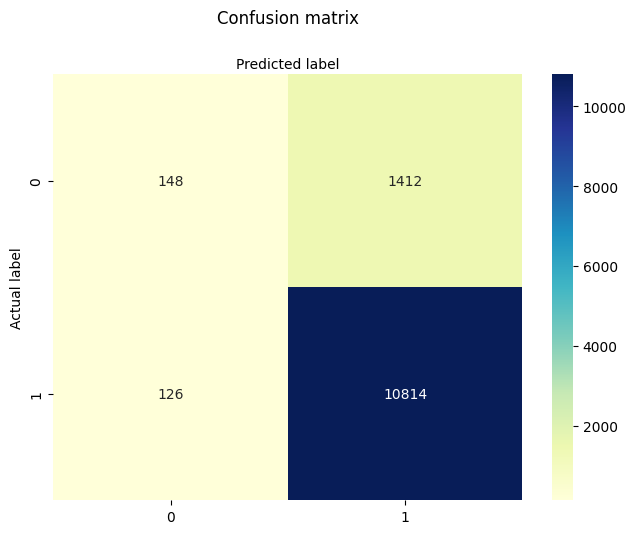

In [ ]:
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [ ]:
from sklearn.metrics import (
accuracy_score,
classification_report,
precision_score,
recall_score,
f1_score,
roc_auc_score,
roc_curve
)

# Accuracy
accuracy = accuracy_score(y2_test, y2_pred)
print(f"Accuracy: {accuracy:.3f}")

# Precision, Recall, F1
print("Precision:", precision_score(y2_test, y2_pred))
print("Recall:", recall_score(y2_test, y2_pred))
print("F1 Score:", f1_score(y2_test, y2_pred))

# Full classification report
print("\nClassification Report:")
print(classification_report(y2_test, y2_pred))

Accuracy: 0.877
Precision: 0.8845084246687388
Recall: 0.9884826325411334
F1 Score: 0.9336096002762669

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.09      0.16      1560
           1       0.88      0.99      0.93     10940

    accuracy                           0.88     12500
   macro avg       0.71      0.54      0.55     12500
weighted avg       0.84      0.88      0.84     12500



In [ ]:
from pandas_gbq import to_gbq

to_gbq(
    df_clean,
    destination_table='data.ai_cleaned',
    project_id='deescapstone',
    if_exists='replace'
)

100%|██████████| 1/1 [00:00<00:00, 5555.37it/s]


In [ ]:
df_clean.to_csv('df_clean.csv', index=False)


from google.colab import files
files.download('df_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>